## makemore: becoming a backprop ninja

In [ ]:
# there no change change in the first several cells from last lecture

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

zsh:1: command not found: wget


In [4]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [7]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size #[stoi['.']] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
# ok biolerplate done, now we get to the action:

In [8]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [9]:
n_embd = 10 # the dimensionality of the character embedding vectors 

#NEDEN 10 ve kaç boyuta gömeceğimize nasıl karar veriyoruz.
# Dev datasında denemeler yapıyorsun aslında, ve boyutu seçtikten sonra gömülme dediğin şey anlam yakınlığı kurarak kendiliğinde oluyor zaten train edildikçe.


n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total # Buradaki bütün parametreler model ile optimize edilecek, insanlar gidip seçmiyor.
for p in parameters:
  p.requires_grad = True

4137


In [10]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y #AYNI VERI BİRDEN ÇOK BATCH İÇİNDE GELEBİLİR.

# biz aslında kaç kez data göreceğini seçiyoruz. 32 x biz ne kadar tur istersek rastgele bizim datalardan gösteritoruz. 
# ve çok kez adım atıyoruz. aynı örneği de çok kez görebiliriz normal.

In [ ]:
# Neden batch
# 182 bin örneğin hepsiyle her adımda forward+backward yapmak çok yavaş. 32 örnekle yaklaşık 5700 kat hızlı.
# Bedeli: gradient gürültülü oluyor. 32 örnek tüm veriyi mükemmel temsil etmiyor, o yüzden hesapladığın yön biraz sapıyor.
# Ama takas kârlı: gürültülü ama çok daha fazla adım atabiliyorsun. Toplamda çok daha hızlı öğreniyorsun.
# Karpathy'nin sözü: "yaklaşık doğru yönde çok adım atmak, tam doğru yönde az adım atmaktan iyidir."

In [ ]:
# Batch boyutunun ayrı etkisi
# Adım sayısıyla karıştırma. Batch boyutu gradientin kalitesini belirliyor.
# Küçük batch (8): çok gürültülü gradient, ama her adım hızlı
# Büyük batch (512): temiz gradient, ama her adım yavaş
# 32 ile 128 arası yaygın bir aralık. Karpathy 32 kullanıyor.
# Bir de şu: batch büyüdükçe gradient daha güvenilir olduğu için learning rate'i de büyütebiliyorsun. İkisi bağlantılı.

In [ ]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors # Xb = [32,3] cünkü her batch 32 veriden oluştu her biri de 3 harften. [32, 3, 10] oldu artik 10 deger gömecek model cunku.
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors #Düzleştirme. [32, 3, 10] → [32, 30]. Üç harfin onar sayısı yan yana diziliyor. 

#view babayı görmüştük daha önceden zaten, sadece boyutları değiştiriyor. bellekt değişim yok data için. -1 de otomatik boyut hesaplamak için

# Linear layer 1
hprebn = embcat @ W1 + b1 # "hidden pre-batchnorm" demek. [32, 30] @ [30, 64] = [32, 64]. Artı bias.

# BATCHNORM LAYER !!!!
bnmeani = 1/n*hprebn.sum(0, keepdim=True)  #Ortalama. sum(0) — batch ekseni boyunca, yani her nöron için ayrı ayrı 32 örneğin toplamı. Sonuç [1, 64].
# .mean(0) yerine elle yazılmış, çünkü türevini elle alacaksın.

bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3636, grad_fn=<NegBackward0>)

In [ ]:
# 1. embcat @ W1                    → ham hpreact (geniş, kontrolsüz)
# 2. normalize et (mean/std ile)    → hpreact artık kontrollü
# 3. tanh(hpreact)                  → h

In [13]:
Yb

tensor([ 8, 14, 15, 22,  0, 19,  9, 14,  5,  1, 20,  3,  8, 14, 12,  0, 11,  0,
        26,  9, 25,  0,  1,  1,  7, 18,  9,  3,  5,  9,  0, 18])

In [14]:
logprobs.shape

torch.Size([32, 27])

In [16]:
logprobs[range(n), Yb]

tensor([-4.0371, -3.0284, -3.7643, -3.1786, -4.1239, -3.5651, -3.1788, -4.0067,
        -3.2098, -4.3086, -3.2174, -1.7010, -2.8673, -3.0213, -2.9224, -3.2130,
        -3.9136, -3.0771, -3.5947, -3.3279, -2.9119, -3.0509, -4.3455, -4.0223,
        -3.4816, -2.8776, -3.0686, -3.8863, -2.8270, -3.4296, -3.3991, -3.0779],
       grad_fn=<IndexBackward0>)

In [ ]:
#loss = -1/3a + -1/3b + -1/3c
#dloss / da = -1/3

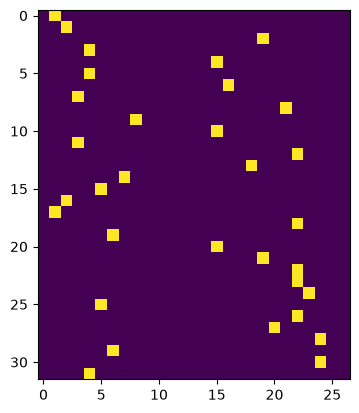

In [22]:
plt.imshow(F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]))

In [40]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdims=True) #EN ZORLANDIIGM YER
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts += torch.ones_like(counts) * dcounts_sum #dcounts ikinci katkısı. += var dikkat et kap mevzuyu.
dnorm_logits = counts * dcounts #e^x in turevi zaten kendisi ya ondan direkt counts döndü bi de chain ruledan lossa bi adım daha yakın olanın kısmi türevi
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True) # norm_logits = logits - logit_maxes norm logitsin logit maxesa gore turevi alınacak o da -1. bi de bu chain rule için dnorm_logits ile çarpılacak. gerisi broadcaasting
dlogits = dnorm_logits.clone()
# aynı satırdan logits'e türev +1, doğrudan geçiyor

dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes
# logit_maxes = logits.max(1) → her satırdan sadece 1 eleman (max) seçildi
# one_hot: "maksimum hangi sütundaydı" maskesi, gradient sadece o hücreye yazılsın diye
dh = dlogits @ W2.T # [32, 64] = [32, 27] @ [27, 64].   h.shape eşit olmalı dh.shape'e
dW2 = h.T @ dlogits # [64, 27] = [32, 64].t() @ [32, 27]
db2 = dlogits.sum(0) # [27] = [32, 27].sum(0)

dhpreact = (1 - h**2) * dh # tanh'in türevi 1-tanh^2

dbngain = (bnraw * dhpreact).sum(0, keepdim=True) # [1, 64] = [32, 64] * [32, 64].sum(0)
dbnraw = bngain * dhpreact # [32, 64] = [1, 64] * [32, 64]
dbnbias = dhpreact.sum(0, keepdim=True) # [1, 64] = [32, 64].sum(0)

dbndiff = dbnraw * bnvar_inv # [32, 64] = [32, 64] * [1, 64]
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True) # [1, 64] = [32, 64] * [32, 64].sum(0)
dbnvar = (-0.5 * (bnvar + 1e-5)**-1.5) * dbnvar_inv # [1, 64] = [1, 64] * [1, 64]

dbndiff2 = (1.0/(n-1)) * torch.ones_like(bndiff2) * dbnvar
dbndiff += (2 * bndiff) * dbndiff2 # [32, 64] = 2 * [32, 64] * [32, 64].  += eklemen lazım second branch bu aynı var için.

dhprebn = dbndiff.clone() # [32, 64] = [32, 64]
dbnmeani = (-dbndiff).sum(0, keepdim=True) # [1, 64] = -[32, 64] * [32, 64].sum(0)

dhprebn += (1.0/n) * torch.ones_like(hprebn) * dbnmeani
# linear layerları backprop yapmak kolay, formülleri ezberlemek yerine matris şekillerini denk getir çıkıyor zaten formül.

dembcat = dhprebn @ W1.T # [32, 30] = [32, 64] @ [64, 30]
dW1 = embcat.T @ dhprebn # [30, 64] = [32, 30].t() @ [32, 64]
db1 = dhprebn.sum(0) # [64] = [32, 64].sum(0)

demb = dembcat.view(emb.shape ) #embcat = emb.view(emb.shape[0], -1) idi. # concatenate kısmını geri alıcaz sadece. matsal bi kısım yok.

dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k, j]
    dC[ix] += demb[k, j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [ ]:
dh = dlogits @ W2.T # [32, 64] = [32, 27] @ [27, 64].   h.shape eşit olmalı dh.shape'e
dW2 = h.T @ dlogits # [64, 27] = [32, 64].t() @ [32, 27]
db2 = dlogits.sum(0) # [27] = [32, 27].sum(0)

In [23]:
dlogits.shape, h.shape, W2.shape, b2.shape

(torch.Size([32, 27]),
 torch.Size([32, 64]),
 torch.Size([64, 27]),
 torch.Size([27]))

In [42]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3636016845703125 diff: 0.0


In [46]:
# backward pass

# -----------------
# YOUR CODE HERE :)
dlogits = F.softmax (logits,1) # softmax
dlogits[range(n), Yb] -= 1 # cross entropy
dlogits /= n # average
# -----------------

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 7.916241884231567e-09


In [47]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [48]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1) * bnraw * (dhpreact*bnraw).sum(0))
# -----------------

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-10


In [53]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    # for p in parameters:
    #   p.grad = None
    # loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    # YOUR CODE HERE :)
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n

    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)

    dhpreact = (1.0 - h**2) * dh

    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)

    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
        for j in range(Xb.shape[1]):
            ix = Xb[k, j]
            dC[ix] += demb[k, j]

    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
    #   break

12297
      0/ 200000: 3.7675
  10000/ 200000: 2.2104
  20000/ 200000: 2.4277
  30000/ 200000: 2.4425
  40000/ 200000: 2.0158
  50000/ 200000: 2.3738
  60000/ 200000: 2.3938
  70000/ 200000: 2.0587
  80000/ 200000: 2.3135
  90000/ 200000: 2.0346
 100000/ 200000: 2.0097
 110000/ 200000: 2.2906
 120000/ 200000: 2.0321
 130000/ 200000: 2.4422
 140000/ 200000: 2.3034
 150000/ 200000: 2.1606
 160000/ 200000: 1.9233
 170000/ 200000: 1.8227
 180000/ 200000: 1.9800
 190000/ 200000: 1.8920


In [54]:
# useful for checking your gradients
for p,g in zip(parameters, grads):
  cmp(str(tuple(p.shape)), g, p)

TypeError: all() received an invalid combination of arguments - got (bool), but expected one of:
 * (Tensor input, *, Tensor out = None)
 * (Tensor input, tuple of ints dim = None, bool keepdim = False, *, Tensor out = None)
 * (Tensor input, int dim, bool keepdim = False, *, Tensor out = None)


In [55]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [56]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.071309804916382
val 2.111567735671997


In [ ]:
# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145

In [58]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carlah.
amorie.
khi.
mri.
reity.
salaysie.
mahnen.
delynn.
jareei.
nellara.
chaiivon.
leigh.
ham.
joce.
quinn.
salin.
alianni.
waythoniearisi.
jace.
pirsan.
